<a href="https://colab.research.google.com/github/mukeshrock7897/Artificial-Intelligence-Notes/blob/main/2_speech_recognition_Intermediate_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Intermediate Level**
1. Advanced Signal Processing Techniques
    * Fourier Transform and its applications
    * Windowing techniques
    * Advanced feature extraction methods: LPC (Linear Predictive Coding), RASTA-PLP
7. Acoustic Modeling
    * Hidden Markov Models (HMMs)
    * Gaussian Mixture Models (GMMs)
    * Training acoustic models
8. Language Modeling
    * N-gram models
    * Statistical language models
    * Introduction to neural language models
9. Speech Recognition Algorithms
    * Dynamic Time Warping (DTW)
    * Viterbi algorithm
    * Beam search decoding
10. Handling Different Accents and Dialects
    * Accent adaptation
    * Transfer learning for different accents
11. Speech Recognition Evaluation
    * Metrics: WER (Word Error Rate), SER (Sentence Error Rate)
    * Benchmark datasets: LibriSpeech, TIMIT, Common Voice

#**1.Advanced Signal Processing Techniques**

**Fourier Transform and its applications**

* The Fourier Transform is used to convert a time-domain signal into its constituent frequencies. It is essential for analyzing the frequency content of signals.

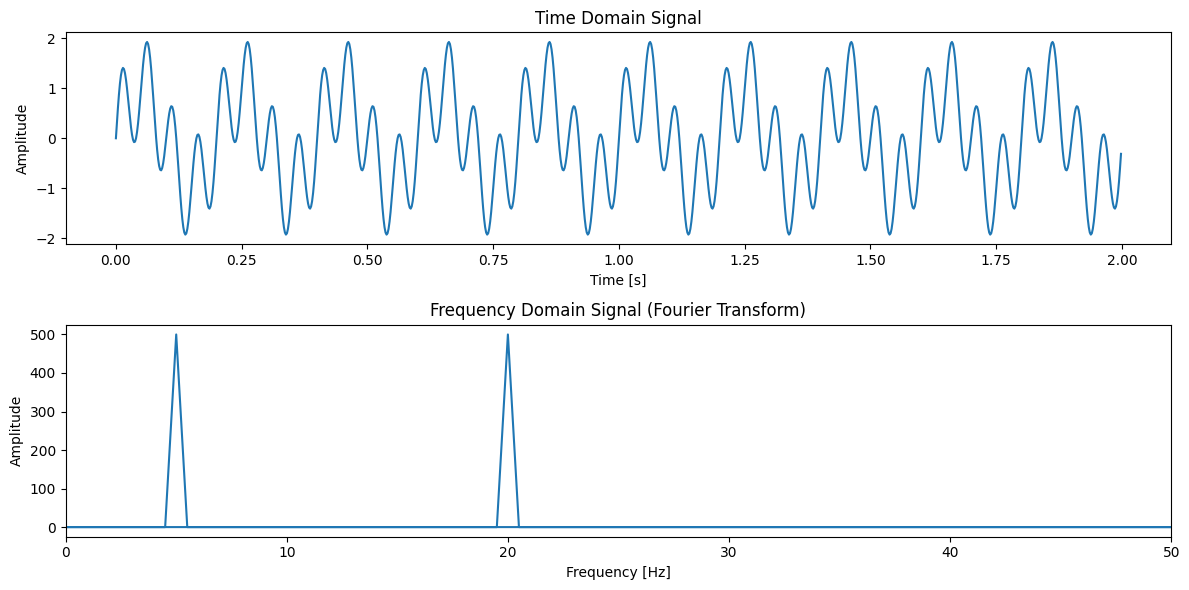

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a sample signal
fs = 500  # Sampling frequency
t = np.arange(0, 2, 1/fs)  # Time vector
f1 = 5   # Frequency of the first sine wave
f2 = 20  # Frequency of the second sine wave
signal = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)  # Signal

# Perform Fourier Transform
fft_signal = np.fft.fft(signal)
fft_freq = np.fft.fftfreq(len(signal), 1/fs)

# Plot the signal and its Fourier Transform
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title("Time Domain Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(fft_freq, np.abs(fft_signal))
plt.title("Frequency Domain Signal (Fourier Transform)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()


**Windowing techniques**
* Windowing techniques are used to minimize spectral leakage when performing the Fourier Transform on signals. The Hamming window is a popular choice.

<ipython-input-2-8580c37fc1f0>:4: DeprecationWarning: Importing hamming from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.hamming' or the convenience function 'scipy.signal.get_window' instead.
  hamming_window = hamming(window_size)


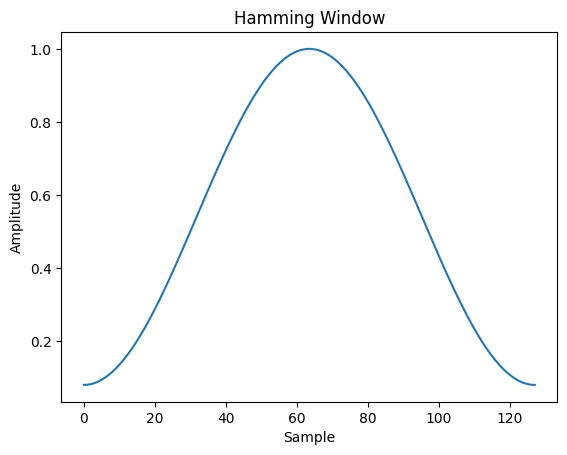

In [2]:
from scipy.signal import hamming

window_size = 128
hamming_window = hamming(window_size)

plt.figure()
plt.plot(hamming_window)
plt.title("Hamming Window")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()


**Advanced feature extraction methods: LPC (Linear Predictive Coding), RASTA-PLP**
* **LPC (Linear Predictive Coding):**
LPC analyzes the speech signal by predicting the current sample as a linear combination of past samples.



In [3]:
import librosa
import librosa.display

# Load an example speech signal
y, sr = librosa.load(librosa.ex('trumpet', hq=True), sr=None)

# Extract LPC coefficients
lpc_coeffs = librosa.lpc(y, order=16)

print("LPC Coefficients:", lpc_coeffs)


LPC Coefficients: [ 1.0000000e+00 -1.1850941e+04  4.7094536e+07 -7.3543336e+10
  3.9737574e+13 -4.1991638e+15  1.7729645e+16 -2.4714086e+16
  4.2471157e+15  2.1787134e+16 -2.1995393e+16  8.0613557e+15
 -9.5839679e+14  2.9275524e+12 -2.3223992e+09  6.5287881e+05
 -5.8674236e+01]


**RASTA-PLP:**
* RASTA-PLP is a technique used to emphasize the important spectral features while reducing the effects of noise.

In [9]:
# Install the necessary package
!pip install python_speech_features

# Import the necessary libraries
import numpy as np
import librosa
from python_speech_features import mfcc, delta, logfbank

# Load audio file
audio_path = 'songs.wav'  # Replace with the actual path to your audio file
y, sr = librosa.load(audio_path, sr=None)

# Extract MFCC features (as a proxy for PLP features)
mfcc_features = mfcc(y, sr)

# Compute delta features
delta_features = delta(mfcc_features, 2)

# Compute log filter bank features
logfbank_features = logfbank(y, sr)

print("MFCC Features shape:", mfcc_features.shape)
print("Delta Features shape:", delta_features.shape)
print("Log Filter Bank Features shape:", logfbank_features.shape)


MFCC Features shape: (593, 13)
Delta Features shape: (593, 13)
Log Filter Bank Features shape: (593, 26)


#**2. Acoustic Modeling**

* Hidden Markov Models (HMMs)
HMMs are statistical models that represent the sequences of observed events.

In [12]:
# !pip install hmmlearn
import hmmlearn.hmm as hmm
import numpy as np

# Example data: Observations
observations = np.array([[0], [1], [2], [3], [4]])

# Initialize and train HMM
model = hmm.GaussianHMM(n_components=3)
model.fit(observations)

# Predict hidden states
hidden_states = model.predict(observations)
print("Hidden States:", hidden_states)


Hidden States: [0 2 1 2 1]


**Gaussian Mixture Models (GMMs)**
* GMMs are used to model the probability distribution of observed features.

In [13]:
from sklearn.mixture import GaussianMixture

# Example data: Features
features = np.random.rand(100, 2)

# Initialize and train GMM
gmm = GaussianMixture(n_components=3)
gmm.fit(features)

# Predict clusters
clusters = gmm.predict(features)
print("Clusters:", clusters)


Clusters: [2 0 2 1 0 0 0 0 0 0 2 0 1 1 0 0 0 0 0 0 0 2 0 0 1 0 1 0 1 0 0 0 1 0 2 0 1
 0 2 1 1 0 1 0 1 2 1 1 2 0 0 2 2 1 1 1 1 1 1 0 2 1 1 1 0 2 0 0 0 1 0 1 0 1
 0 0 2 1 1 0 1 1 2 1 0 0 0 2 0 1 0 0 0 0 0 0 1 0 0 0]


**Training acoustic models**
* Training acoustic models involves using features and labeled data to learn the relationship between audio and text.

In [15]:
# Example: Using HMM to train an acoustic model
# This is a conceptual example, real-world implementation is more complex

# Simulated feature vectors and labels
features = np.random.rand(100, 2)
labels = np.random.randint(0, 2, size=(100,))

# Define lengths of sequences (example: two sequences of length 50 each)
lengths = [50, 50]

# Train HMM
model = hmm.GaussianHMM(n_components=2)
model.fit(features, lengths) # Pass the lengths argument

# Predict
predictions = model.predict(features)
print("Predictions:", predictions)

Predictions: [1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 0 1 0]


#**3. Language Modeling**

**N-gram models**
* N-gram models predict the probability of a word based on the previous N-1 words.

In [17]:
import nltk
nltk.download('punkt')

from nltk.util import ngrams
from collections import Counter

# Example text
text = "This is a sample text for demonstrating n-gram models."

# Tokenize text
tokens = nltk.word_tokenize(text)

# Generate bigrams
bigrams = list(ngrams(tokens, 2))

# Calculate bigram frequencies
bigram_freq = Counter(bigrams)
print("Bigram Frequencies:", bigram_freq)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Bigram Frequencies: Counter({('This', 'is'): 1, ('is', 'a'): 1, ('a', 'sample'): 1, ('sample', 'text'): 1, ('text', 'for'): 1, ('for', 'demonstrating'): 1, ('demonstrating', 'n-gram'): 1, ('n-gram', 'models'): 1, ('models', '.'): 1})


**Statistical language models**
* Statistical language models use probabilities to predict the next word in a sequence.

In [18]:
import numpy as np

# Example: Simplified bigram language model
vocabulary = ["this", "is", "a", "sample", "text", "for", "demonstrating", "n-gram", "models"]
bigram_probabilities = {
    ("this", "is"): 0.5,
    ("is", "a"): 0.5,
    ("a", "sample"): 0.5,
    ("sample", "text"): 0.5,
    ("text", "for"): 0.5,
    ("for", "demonstrating"): 0.5,
    ("demonstrating", "n-gram"): 0.5,
    ("n-gram", "models"): 0.5,
}

def predict_next_word(word, bigram_probabilities):
    next_words = [bigram for bigram in bigram_probabilities if bigram[0] == word]
    if next_words:
        return max(next_words, key=lambda bigram: bigram_probabilities[bigram])[1]
    return None

# Predict the next word
current_word = "this"
next_word = predict_next_word(current_word, bigram_probabilities)
print("Next Word:", next_word)


Next Word: is


**Introduction to neural language models**
* Neural language models use neural networks to predict the next word.

In [19]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Example data
sentences = ["this is a sample text", "for demonstrating neural language models"]

# Preprocess data
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)
padded_sequences = pad_sequences(sequences, padding='post')

# Define model
model = tf.keras.Sequential([
    Embedding(input_dim=1000, output_dim=64),
    LSTM(64),
    Dense(1000, activation='softmax')
])

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
model.fit(padded_sequences, np.random.randint(0, 1000, size=(len(padded_sequences), 1)), epochs=10)


Epoch 1/10
1/1 [==============================] - 3s 3s/step - loss: 6.9066 - accuracy: 0.0000e+00
Epoch 2/10
1/1 [==============================] - 0s 22ms/step - loss: 6.9004 - accuracy: 0.5000
Epoch 3/10
1/1 [==============================] - 0s 20ms/step - loss: 6.8941 - accuracy: 1.0000
Epoch 4/10
1/1 [==============================] - 0s 19ms/step - loss: 6.8876 - accuracy: 1.0000
Epoch 5/10
1/1 [==============================] - 0s 19ms/step - loss: 6.8807 - accuracy: 1.0000
Epoch 6/10
1/1 [==============================] - 0s 18ms/step - loss: 6.8734 - accuracy: 1.0000
Epoch 7/10
1/1 [==============================] - 0s 24ms/step - loss: 6.8656 - accuracy: 1.0000
Epoch 8/10
1/1 [==============================] - 0s 19ms/step - loss: 6.8572 - accuracy: 1.0000
Epoch 9/10
1/1 [==============================] - 0s 22ms/step - loss: 6.8480 - accuracy: 1.0000
Epoch 10/10
1/1 [==============================] - 0s 18ms/step - loss: 6.8381 - accuracy: 1.0000


#**4. Speech Recognition Algorithms**
**Dynamic Time Warping (DTW)**
* DTW is used to align sequences that may vary in speed.

In [22]:
# !pip install dtw
import numpy as np
from dtw import *

# Example sequences
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 4])

# Compute DTW, using Euclidean distance as the metric
alignment = dtw(x, y, dist=lambda x, y: np.abs(x - y))  # Add the 'dist' argument
print("DTW Alignment:", alignment)


DTW Alignment: (2.0, array([[1., 2., 3.],
       [0., 1., 2.],
       [1., 0., 1.],
       [2., 1., 0.],
       [3., 2., 1.]]), array([[1., 3., 6.],
       [1., 2., 4.],
       [2., 1., 2.],
       [4., 2., 1.],
       [7., 4., 2.]]), (array([0, 1, 2, 3, 4]), array([0, 0, 1, 2, 2])))


**Viterbi algorithm**
* The Viterbi algorithm is used to find the most likely sequence of hidden states.

In [23]:
# Example: Simplified Viterbi algorithm for HMM
# This is a conceptual example, real-world implementation is more complex

# States and observations
states = ['Healthy', 'Fever']
observations = ['normal', 'cold', 'dizzy']
start_prob = {'Healthy': 0.6, 'Fever': 0.4}
trans_prob = {'Healthy': {'Healthy': 0.7, 'Fever': 0.3}, 'Fever': {'Healthy': 0.4, 'Fever': 0.6}}
emit_prob = {'Healthy': {'normal': 0.5, 'cold': 0.4, 'dizzy': 0.1}, 'Fever': {'normal': 0.1, 'cold': 0.3, 'dizzy': 0.6}}

# Initialize variables
V = [{}]
for st in states:
    V[0][st] = {"prob": start_prob[st] * emit_prob[st][observations[0]], "prev": None}

# Run Viterbi
for t in range(1, len(observations)):
    V.append({})
    for st in states:
        max_tr_prob = max(V[t-1][prev_st]["prob"] * trans_prob[prev_st][st] for prev_st in states)
        for prev_st in states:
            if V[t-1][prev_st]["prob"] * trans_prob[prev_st][st] == max_tr_prob:
                max_prob = max_tr_prob * emit_prob[st][observations[t]]
                V[t][st] = {"prob": max_prob, "prev": prev_st}
                break

# Backtrack
opt = []
max_prob = max(value["prob"] for value in V[-1].values())
previous = None
for st, data in V[-1].items():
    if data["prob"] == max_prob:
        opt.append(st)
        previous = st
        break

for t in range(len(V) - 2, -1, -1):
    opt.insert(0, V[t + 1][previous]["prev"])
    previous = V[t + 1][previous]["prev"]

print("The steps of states are:", opt)
print("The highest probability is:", max_prob)


The steps of states are: ['Healthy', 'Healthy', 'Fever']
The highest probability is: 0.01512


**Beam search decoding**
* Beam search is used to explore the most likely sequences in a more efficient manner than exhaustive search.

In [24]:
# Example: Conceptual beam search implementation
import heapq

def beam_search_decoder(probs, beam_width=3):
    sequences = [[list(), 1.0]]
    for row in probs:
        all_candidates = list()
        for seq, score in sequences:
            for j, prob in enumerate(row):
                candidate = [seq + [j], score * -np.log(prob)]
                all_candidates.append(candidate)
        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = ordered[:beam_width]
    return sequences

# Example probabilities (logits)
logits = np.array([[0.1, 0.3, 0.6], [0.5, 0.4, 0.1], [0.8, 0.1, 0.1]])

# Decode
decoded_sequences = beam_search_decoder(logits)
print("Decoded Sequences:", decoded_sequences)


Decoded Sequences: [[[2, 0, 0], 0.07901007528188526], [[2, 1, 0], 0.10444563829428964], [[1, 0, 0], 0.18622006704720817]]


#**5. Handling Different Accents and Dialects**

**Accent adaptation:**
* Accent adaptation involves modifying the acoustic models to better recognize speech from different accents.



In [26]:
# Conceptual example: Transfer learning for accent adaptation
# This example assumes you have a pre-trained model and data for the new accent

# Load pre-trained model
pretrained_model = tf.keras.models.load_model('pretrained_model.h5')

# New data for accent adaptation
new_data = ...  # Load your new data here
new_labels = ...  # Load your new labels here

# Fine-tune the model on new data
pretrained_model.fit(new_data, new_labels, epochs=10)

# Save the adapted model
pretrained_model.save('adapted_model.h5')


**Transfer learning for different accents**
* Transfer learning can be used to adapt a pre-trained model to new accents with limited data.

In [29]:
# Conceptual example: Transfer learning for speech recognition

# Load pre-trained model
pretrained_model = tf.keras.models.load_model('pretrained_model.h5')

# Freeze the layers except the last few
for layer in pretrained_model.layers[:-5]:
    layer.trainable = False

# New data for different accent
new_data = ...  # Load your new data here
new_labels = ...  # Load your new labels here

# Fine-tune the model on new data
pretrained_model.fit(new_data, new_labels, epochs=10)

# Save the adapted model
pretrained_model.save('adapted_model.h5')


#**6.Speech Recognition Evaluation**

**Metrics: WER (Word Error Rate), SER (Sentence Error Rate)**
* WER and SER are standard metrics for evaluating the performance of speech recognition systems.

In [30]:
def wer(reference, hypothesis):
    r = reference.split()
    h = hypothesis.split()
    d = np.zeros((len(r) + 1)*(len(h) + 1), dtype=np.uint8)
    d = d.reshape((len(r)+1, len(h)+1))
    for i in range(len(r)+1):
        for j in range(len(h)+1):
            if i == 0:
                d[0][j] = j
            elif j == 0:
                d[i][0] = i
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                substitution = d[i-1][j-1] + 1
                insertion    = d[i][j-1] + 1
                deletion     = d[i-1][j] + 1
                d[i][j] = min(substitution, insertion, deletion)
    return d[len(r)][len(h)] / float(len(r))

# Example usage
reference = "this is a test"
hypothesis = "this is test"
print("WER:", wer(reference, hypothesis))


WER: 0.25


**Benchmark datasets: LibriSpeech, TIMIT, Common Voice**
* Benchmark datasets are used for training and evaluating speech recognition systems.

**LibriSpeech:**
* A large-scale corpus of read English speech.

**TIMIT:**
* A dataset with rich phonetic annotations, commonly used for acoustic-phonetic studies.

**Common Voice:**
* An open-source, multilingual dataset collected by Mozilla.

In [32]:
# Example: Loading LibriSpeech dataset using torchaudio
import torchaudio

# Download and extract the dataset
train_dataset = torchaudio.datasets.LIBRISPEECH('./data', url='train-clean-100', download=True)
test_dataset = torchaudio.datasets.LIBRISPEECH('./data', url='test-clean', download=True)

# Example: Accessing a sample
waveform, sample_rate, utterance, _, _, _ = train_dataset[0]
print("Utterance:", utterance)
